In [2]:
import pandas as pd
medical_df = pd.read_csv('medical.csv')
medical_df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [3]:
medical_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [4]:
medical_df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [5]:
import plotly.express as px
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
%matplotlib inline

In [6]:
fig1 = px.histogram(medical_df, x='age', nbins=47, title='Age Distribution', marginal='box')
fig1.update_layout(bargap=0.1)
fig1.show()

In [7]:
fig2 = px.histogram(medical_df, x='bmi', title='BMI Distribution', marginal='box')
fig2.update_layout(bargap=0.1)
fig2.show()

In [8]:
fig3 = px.histogram(medical_df,
                     x='charges',
                     marginal='box',
                     color='smoker',
                     color_discrete_sequence=['blue', 'red'],
                     title='Charges Distribution by Smoking Status')
fig3.update_layout(bargap=0.1)
fig3.show()

In [9]:
medical_df.smoker.value_counts()

smoker
no     1064
yes     274
Name: count, dtype: int64

In [10]:
fig = px.scatter(medical_df,
                x='age',
                y='charges', 
                color='smoker',
                title='Charges by Age and Smoking Status',
                opacity=0.7)
fig.update_traces(marker_size=5)
fig.show()

In [11]:
fig = px.scatter(medical_df, x='bmi', y='charges', color='smoker', title='Charges by BMI and Smoking Status', opacity=0.7, hover_data=['sex'])
fig.update_traces(marker_size=5)
fig.show()

In [12]:
medical_df.charges.corr(medical_df.age)

np.float64(0.2990081933306478)

In [13]:
smoker_values = {'no': 0, 'yes': 1}
smoker_numeric = medical_df.smoker.map(smoker_values)
medical_df['smoker_numeric'] = smoker_numeric
medical_df.charges.corr(medical_df.smoker_numeric)

np.float64(0.7872514304984778)

In [14]:
corr = medical_df.select_dtypes(include=['number']).corr()

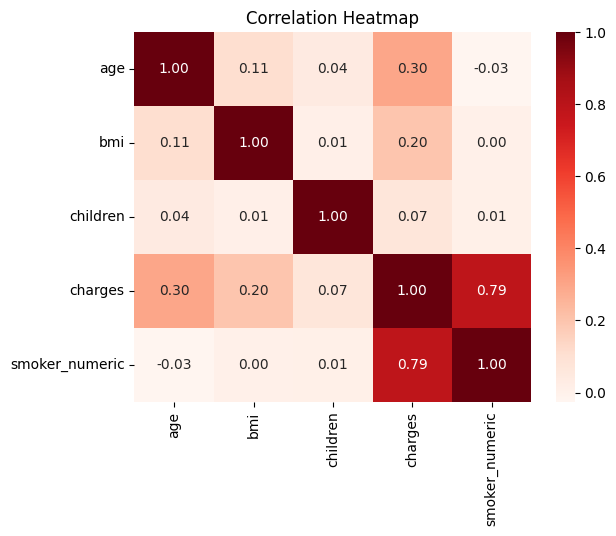

In [15]:
sns.heatmap(corr, cmap='Reds', annot=True, fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

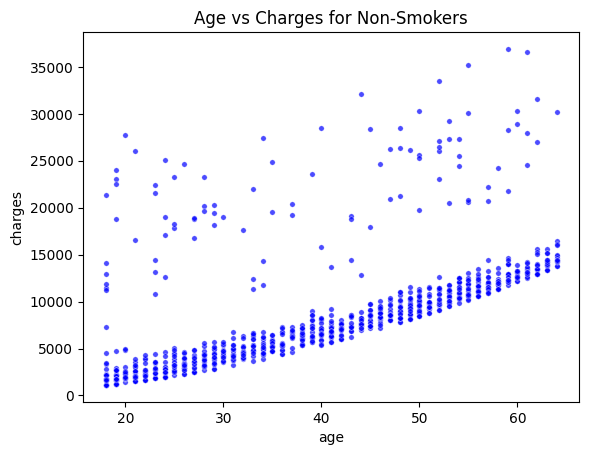

In [16]:
non_smoker_df = medical_df[medical_df.smoker == 'no']
plt.title('Age vs Charges for Non-Smokers')
sns.scatterplot(data=non_smoker_df, x='age', y='charges', color='blue', alpha=0.7, s=15)
plt.show()

In [17]:
def estimate_charges(age, w, b):
    return age * w + b

In [18]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
inputs = medical_df[['age']]
target = medical_df['charges']
model.fit(inputs, target)

model.predict(np.array([[40], [50], [60]]))

c:\Users\elvis\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([13474.78975274, 16052.01593941, 18629.24212608])

In [19]:
predictions = model.predict(inputs)
predictions

array([ 8062.61476073,  7804.89214207, 10382.11832874, ...,
        7804.89214207,  8578.05999807, 18886.96474474], shape=(1338,))

In [20]:
predictions = model.predict(inputs)
predictions

array([ 8062.61476073,  7804.89214207, 10382.11832874, ...,
        7804.89214207,  8578.05999807, 18886.96474474], shape=(1338,))

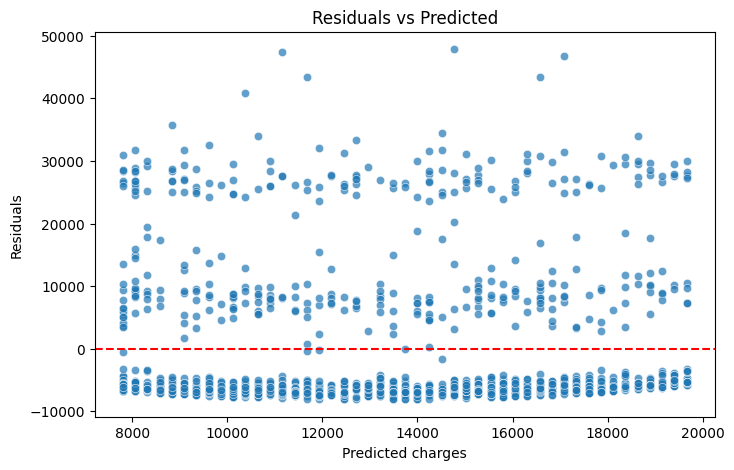

In [21]:
# Residuals vs Predicted
predictions = model.predict(inputs)
residuals = target.values - predictions.flatten()
plt.figure(figsize=(8,5))
sns.scatterplot(x=predictions.flatten(), y=residuals, alpha=0.7)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Predicted charges')
plt.ylabel('Residuals')
plt.title('Residuals vs Predicted')
plt.show()

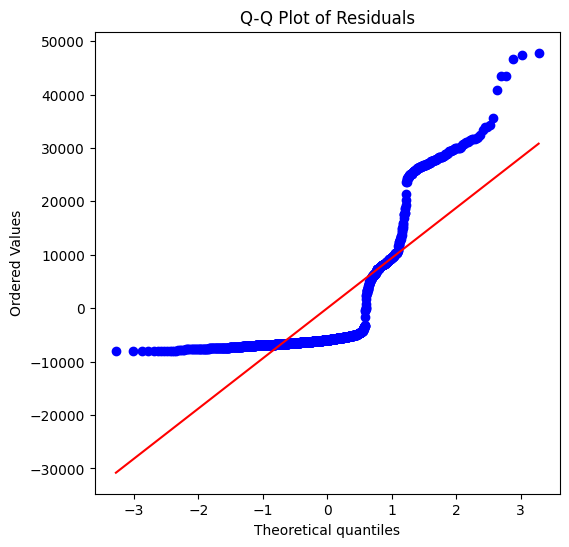

In [22]:
# Q-Q plot of residuals
try:
    import scipy.stats as stats
    plt.figure(figsize=(6,6))
    stats.probplot(residuals, dist='norm', plot=plt)
    plt.title('Q-Q Plot of Residuals')
    plt.show()
except Exception:
    print('scipy is required for Q-Q plot. Install with: pip install scipy')

In [23]:
model.coef_

array([257.72261867])

In [24]:
model.intercept_

np.float64(3165.8850060630284)

In [28]:
import statsmodels.api as sm

X = medical_df[['age', 'sex', 'bmi', 'children', 'smoker', 'region']]
y = medical_df['charges']

# One-hot encode categorical variables
X_encoded = pd.get_dummies(X, drop_first=True).astype(int)

# Add intercept
X_encoded = sm.add_constant(X_encoded)

# Fit OLS model
ols_model = sm.OLS(y, X_encoded).fit()

# Show full regression output
print(ols_model.summary())

                            OLS Regression Results                            
Dep. Variable:                charges   R-squared:                       0.751
Model:                            OLS   Adj. R-squared:                  0.749
Method:                 Least Squares   F-statistic:                     500.7
Date:                Wed, 06 May 2026   Prob (F-statistic):               0.00
Time:                        13:18:56   Log-Likelihood:                -13548.
No. Observations:                1338   AIC:                         2.711e+04
Df Residuals:                    1329   BIC:                         2.716e+04
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const            -1.174e+04    975.287  

In [29]:
fitted_values = ols_model.fittedvalues
residuals = ols_model.resid

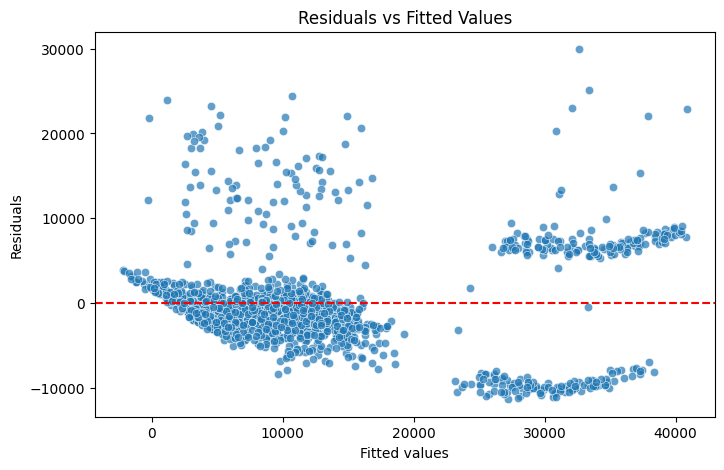

In [30]:
plt.figure(figsize=(8, 5))
sns.scatterplot(x=fitted_values, y=residuals, alpha=0.7)

plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Fitted values')
plt.ylabel('Residuals')
plt.title('Residuals vs Fitted Values')
plt.show()

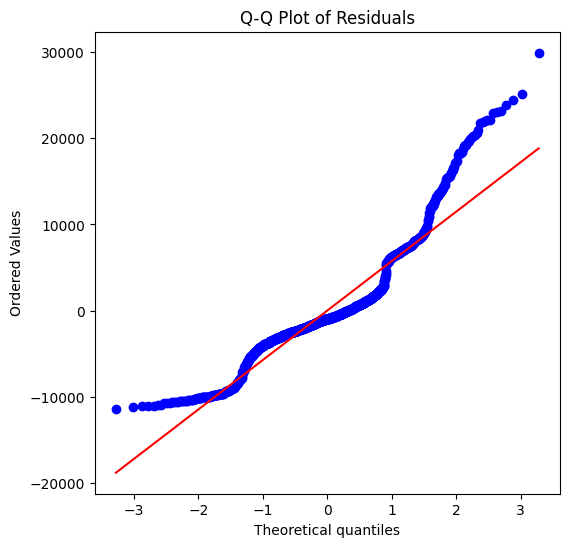

In [31]:
plt.figure(figsize=(6, 6))
stats.probplot(residuals, dist='norm', plot=plt)
plt.title('Q-Q Plot of Residuals')
plt.show()

In [32]:
X = medical_df[['age', 'sex', 'bmi', 'children', 'smoker', 'region']]
y_log = np.log(medical_df['charges'])

X_encoded = pd.get_dummies(X, drop_first=True).astype(int)
X_encoded = sm.add_constant(X_encoded)

log_model = sm.OLS(y_log, X_encoded).fit()

print(log_model.summary())

                            OLS Regression Results                            
Dep. Variable:                charges   R-squared:                       0.768
Model:                            OLS   Adj. R-squared:                  0.767
Method:                 Least Squares   F-statistic:                     550.0
Date:                Wed, 06 May 2026   Prob (F-statistic):               0.00
Time:                        13:25:44   Log-Likelihood:                -808.28
No. Observations:                1338   AIC:                             1635.
Df Residuals:                    1329   BIC:                             1681.
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const                7.0361      0.071  

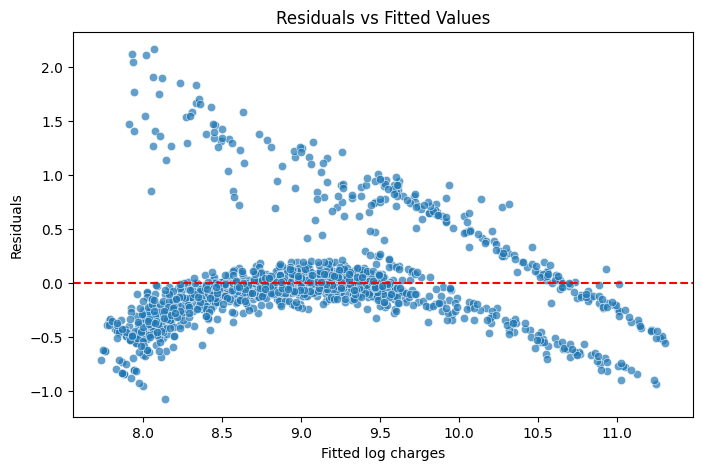

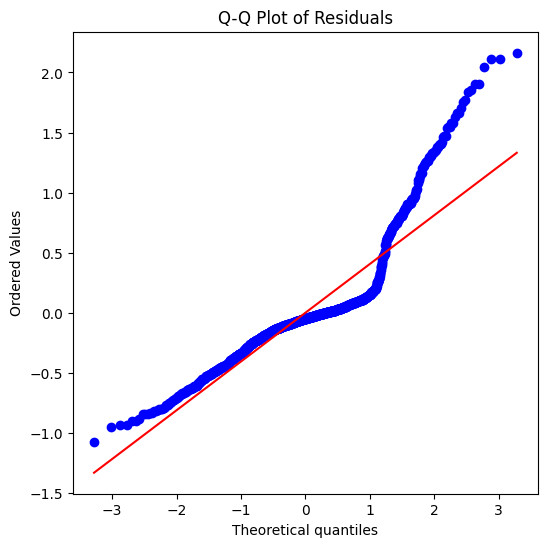

In [33]:
fitted_values = log_model.fittedvalues
residuals = log_model.resid

plt.figure(figsize=(8, 5))
sns.scatterplot(x=fitted_values, y=residuals, alpha=0.7)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Fitted log charges')
plt.ylabel('Residuals')
plt.title('Residuals vs Fitted Values')
plt.show()

plt.figure(figsize=(6, 6))
stats.probplot(residuals, dist='norm', plot=plt)
plt.title('Q-Q Plot of Residuals')
plt.show()

In [38]:
import statsmodels.formula.api as smf

medical_df['log_charges'] = np.log(medical_df['charges'])
medical_df['bmi_centered'] = medical_df['bmi'] - medical_df['bmi'].mean()

interaction_model = smf.ols(
    'log_charges ~ age + bmi_centered + children + sex + smoker + region + smoker:bmi_centered',
    data=medical_df
).fit()

print(interaction_model.summary())

                            OLS Regression Results                            
Dep. Variable:            log_charges   R-squared:                       0.784
Model:                            OLS   Adj. R-squared:                  0.782
Method:                 Least Squares   F-statistic:                     534.0
Date:                Wed, 06 May 2026   Prob (F-statistic):               0.00
Time:                        13:34:46   Log-Likelihood:                -762.05
No. Observations:                1338   AIC:                             1544.
Df Residuals:                    1328   BIC:                             1596.
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------
Intercept           

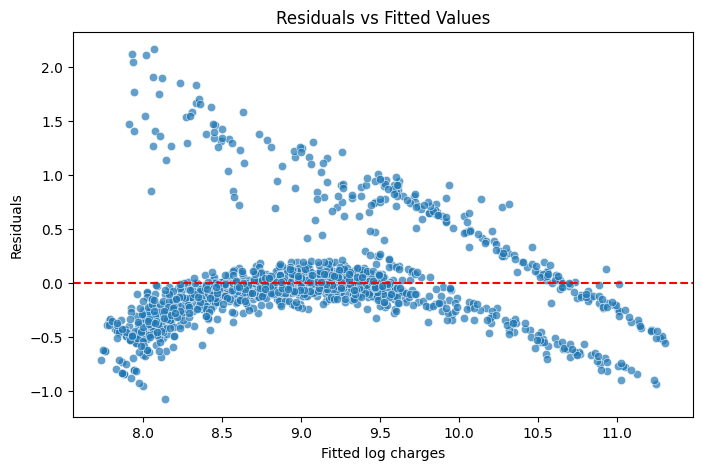

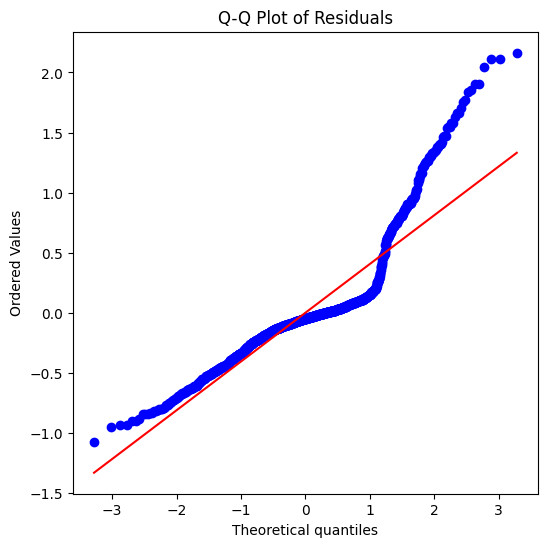

In [39]:
plt.figure(figsize=(8, 5))
sns.scatterplot(x=fitted_values, y=residuals, alpha=0.7)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Fitted log charges')
plt.ylabel('Residuals')
plt.title('Residuals vs Fitted Values')
plt.show()

plt.figure(figsize=(6, 6))
stats.probplot(residuals, dist='norm', plot=plt)
plt.title('Q-Q Plot of Residuals')
plt.show()